# Week 14-1 · EFS-03 — Quantitative Momentum Strategies I (Futures &amp; Roll Returns)

**Instructor: Ernie Chan** (founder/chairman of QTS Capital Management; founder of PredictNow.ai;
author of *Quantitative Trading*, *Algorithmic Trading*, and *Generative AI for Trading*). This is
**Part I of a two-part momentum workshop**, focused on **futures**, where momentum is most prevalent
and best understood. The lecture is taught in MATLAB with `.mat` data — this notebook reproduces all
of the same numerical reasoning in Python (Ernie's own advice: *"in this day and age of LLMs it
doesn't matter what language you program in"*).

**The big picture — a *causal* approach (not data mining, not discretion):**
- Like physics: first propose a **causal model** of *why* prices move, then predict — not just
  observe a phenomenon (Newton's gravity explains the apple *and* the orbits).
- Finance has a **very low signal-to-noise ratio**, so even a good causal model is right only
  **~50–60%** of the time — and that is enough to be in business.
- **Three causes of momentum:** (1) **persistence of roll returns** in futures [today], (2)
  **persistence of factor returns** in stocks [Part II], (3) **institutional forced trading**
  (index/mutual/hedge funds, levered ETFs) creating contagion.

This notebook builds the **roll-return** machinery from the ground up.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)
print("ready")

ready


## 1. Total return = spot return + roll return

A futures total return always decomposes into two parts:

$$\text{Total futures return} = \underbrace{\text{spot return}}_{\text{index/cash moves}} + \underbrace{\text{roll return}}_{\text{the futures-specific piece}}$$

Momentum traders care about the **roll return** — it is persistent and (sometimes) computable
exactly. The cleanest case is the **E-mini S&P 500 (ES)** future, derived by an **arbitrage
argument** against the **SPY** ETF.

In [2]:
# Arbitrage: $1m into SPY  vs  $1m of notional ES futures must give the SAME total return.
#   SPY total return = SPX spot return + dividend yield
#   ES  total return = SPX spot return + roll return + interest earned on the cash (margin collateral)
# Setting them equal and cancelling the SPX spot return:
#   dividend = roll + interest   =>   ROLL RETURN = dividend yield - interest rate
div_yield     = 0.018   # 1.8% annualized S&P dividend yield
interest_rate = 0.045   # 4.5% annualized short rate
roll_emini = div_yield - interest_rate
print("E-MINI (ES) roll return via arbitrage vs SPY")
print(f"  roll = dividend - interest = {div_yield:.3f} - {interest_rate:.3f} = {roll_emini:+.3f} (annualized)")
print(f"  => roll is NEGATIVE here (contango): you LOSE {abs(roll_emini)*100:.1f}%/yr just holding the future")
print("\nKey insight: ES cash sits as MARGIN and still earns interest (no funding cost),")
print("which is why the interest term enters. SPY uses up actual cash, so no interest term.")

E-MINI (ES) roll return via arbitrage vs SPY
  roll = dividend - interest = 0.018 - 0.045 = -0.027 (annualized)
  => roll is NEGATIVE here (contango): you LOSE 2.7%/yr just holding the future

Key insight: ES cash sits as MARGIN and still earns interest (no funding cost),
which is why the interest term enters. SPY uses up actual cash, so no interest term.


In [3]:
# Homework Ernie sets: Mexican peso (MXN) future on the CME.
# Same arbitrage logic -> roll return = interest-rate DIFFERENTIAL (NOT GDP growth).
#   roll(peso future) = foreign rate - domestic rate  (carry)
rate_mxn = 0.110   # Mexican rate
rate_usd = 0.045   # US rate
roll_peso = rate_mxn - rate_usd
print("MXN future roll return = rate_MXN - rate_USD =",
      f"{rate_mxn:.3f} - {rate_usd:.3f} = {roll_peso:+.3f}")
print("This is exactly the FX carry: high-rate currency futures carry a positive roll.")

MXN future roll return = rate_MXN - rate_USD = 0.110 - 0.045 = +0.065
This is exactly the FX carry: high-rate currency futures carry a positive roll.


## 2. Normal backwardation vs contango — and Keynes's wheat story

The **sign** of the roll return has names:
- **Roll > 0 → "normal backwardation"** (front prices *above* far prices; the curve slopes *down*).
- **Roll < 0 → "contango"** (front *below* far; the curve slopes *up*).

Mnemonic: *"backwardation is normal."* **Keynes's story:** a **wheat farmer** is naturally **long**
the physical crop, so he **sells** (shorts) wheat futures to lock in a price. To entice a
**speculator** (who knows *less* about wheat) to take the long side, the future must carry a
**positive expected roll return** as compensation. Hence backwardation is "normal" in commodities.
*(It's only a story — wheat and corn do swing into contango too.)*

## 3. The linear futures-price model and the forward curve

Ernie's simplest non-degenerate model: in **log** space, a futures price is **linear in time**, with
a separate line per contract that all **converge to the spot at expiry**:

$$F(t,T) = \exp\big(\alpha\, t \;-\; \gamma\, T\big) \quad\Longrightarrow\quad
\ln F = \alpha\, t - \gamma\, T$$

where $\alpha$ = **spot return** and $\gamma$ = **roll return** (the thing we want). Two ways to
read $\gamma$:
- **Over time** (one contract's price path): slope $= \alpha + \gamma$ (if spot return $\alpha=0$,
  the slope *is* the roll return).
- **Forward curve / term structure** (a *snapshot* of many contracts vs **time-to-expiry** $T$):
  slope $= -\gamma$. So **roll return = −(slope of the log forward curve)**.

## 4. Why log returns? (additive + can be normal)

Ernie quizzes the class on this. Two reasons:
1. **Additive across time** — 1% then 2% log returns sum to *exactly* 3% (net returns compound, so
   they don't).
2. **Can be normally distributed** — a **net** return is bounded below by **−1** (price can't go
   below 0), so it can never be exactly normal; a **log** return can run to **−∞**, so it can.

In [4]:
# (1) Additivity: log returns add, net returns compound
r1, r2 = 0.01, 0.02
print(f"Log returns: {r1} + {r2} = {r1+r2:.4f} (exactly 3%)")
net_two = (1+r1)*(1+r2) - 1
print(f"Net returns compounded: (1+{r1})(1+{r2})-1 = {net_two:.4f} (>3% due to compounding)")

# (2) Net return is bounded at -1 (price floored at 0); log return is not
p0, p_crash = 100.0, 0.01
print(f"\nPrice 100 -> ~0: net return min = {(0-p0)/p0:+.2f} (floored at -1.00, can't be normal)")
print(f"                  log return       = {np.log(p_crash/p0):+.2f} (heads toward -inf, can be normal)")

Log returns: 0.01 + 0.02 = 0.0300 (exactly 3%)
Net returns compounded: (1+0.01)(1+0.02)-1 = 0.0302 (>3% due to compounding)

Price 100 -> ~0: net return min = -1.00 (floored at -1.00, can't be normal)
                  log return       = -9.21 (heads toward -inf, can be normal)


## 5. Numerical exercise — estimate the roll return of CORN from its forward curve

Ernie loads daily **corn** futures (`.mat`), picks the snapshot **2012-03-14** (row 6387), and asks
the class to estimate the roll return as **−slope of the log forward curve**. We reproduce a corn
forward curve matching his on-screen numbers (front ≈ **669**, far ≈ **564**, prices in cents/bushel,
clearly **downward-sloping → backwardation**).

**Corn realities Ernie stresses:**
- **Month codes:** F=Jan G=Feb H=Mar J=Apr K=May M=Jun N=Jul Q=Aug U=Sep V=Oct X=Nov Z=Dec.
- Corn only lists **H, K, N, U, Z** — expiries are **unevenly spaced** (harvest cycle), not monthly.
- Prices are **settlement** prices (VWAP of the last minutes / bid-ask mid), **not** the last trade.

In [5]:
# Corn forward curve on 2012-03-14 (Ernie's snapshot). Months H/K/N/U/Z, prices in cents.
months   = ["K2012", "N2012", "U2012", "Z2012", "H2013"]   # May, Jul, Sep, Dec, Mar-next
T_years  = np.array([0.17, 0.34, 0.51, 0.76, 1.00])         # time-to-expiry (uneven: harvest cycle)
prices   = np.array([669.0, 642.0, 612.0, 585.0, 564.0])    # downward -> backwardation
corn = pd.DataFrame({"contract": months, "T_years": T_years, "settle": prices})
corn["log_price"] = np.log(corn.settle)
print(corn.to_string(index=False))
print(f"\nFront {prices[0]:.0f} > Far {prices[-1]:.0f}  => downward forward curve => BACKWARDATION")

contract  T_years  settle  log_price
   K2012     0.17   669.0   6.505784
   N2012     0.34   642.0   6.464588
   U2012     0.51   612.0   6.416732
   Z2012     0.76   585.0   6.371612
   H2013     1.00   564.0   6.335054

Front 669 > Far 564  => downward forward curve => BACKWARDATION


In [6]:
# Roll return = -(slope of log forward curve vs time-to-expiry), annualized
slope, intercept = np.polyfit(corn.T_years, corn.log_price, 1)
roll_corn = -slope
print(f"Linear fit of ln(price) on T: slope = {slope:+.4f} per year")
print(f"ROLL RETURN = -slope = {roll_corn:+.4f} = {roll_corn*100:+.1f}% annualized (log)")
print(f"Positive roll confirms BACKWARDATION (normal for an agricultural future).")
# sanity: simple two-point estimate (front vs far) should be in the same ballpark
two_pt = -(corn.log_price.iloc[-1] - corn.log_price.iloc[0]) / (T_years[-1] - T_years[0])
print(f"\nTwo-point check (front vs far): {two_pt:+.4f} ({two_pt*100:+.1f}%) -- consistent")

Linear fit of ln(price) on T: slope = -0.2066 per year
ROLL RETURN = -slope = +0.2066 = +20.7% annualized (log)
Positive roll confirms BACKWARDATION (normal for an agricultural future).

Two-point check (front vs far): +0.2057 (+20.6%) -- consistent


## 6. The causal payoff — why roll return drives futures momentum

The roll return is **persistent**: a future in backwardation tends to *stay* in backwardation for a
while, so its sign predicts the next period's roll contribution. That persistence is the **causal
engine** of futures (CTA-style) momentum — you don't need to predict the noisy **spot** price at
all; you harvest the **roll**. Below: a future whose roll persists builds a steady cumulative roll
return even when the spot return is pure noise.

In [7]:
rng = np.random.default_rng(14)
n = 252
# spot return: pure noise (we predict NOTHING about it); roll: small, persistent, positive
spot_ret = rng.normal(0, 0.012, n)
roll_ret = np.full(n, roll_corn/252)            # steady positive roll (backwardation), per day
total_ret = spot_ret + roll_ret
cum_spot = np.cumprod(1+spot_ret) - 1
cum_roll = np.cumprod(1+roll_ret) - 1
cum_total = np.cumprod(1+total_ret) - 1
print(f"After 1 year:  spot {cum_spot[-1]*100:+.1f}% (noise)  |  "
      f"roll {cum_roll[-1]*100:+.1f}% (harvested)  |  total {cum_total[-1]*100:+.1f}%")
print("The roll piece is the predictable, causal edge -- spot is just noise around it.")

After 1 year:  spot +8.1% (noise)  |  roll +22.9% (harvested)  |  total +32.9%
The roll piece is the predictable, causal edge -- spot is just noise around it.


## 7. Summary chart — the forward curve, log-curve fit, and harvested roll

saved chart_1_roll.png


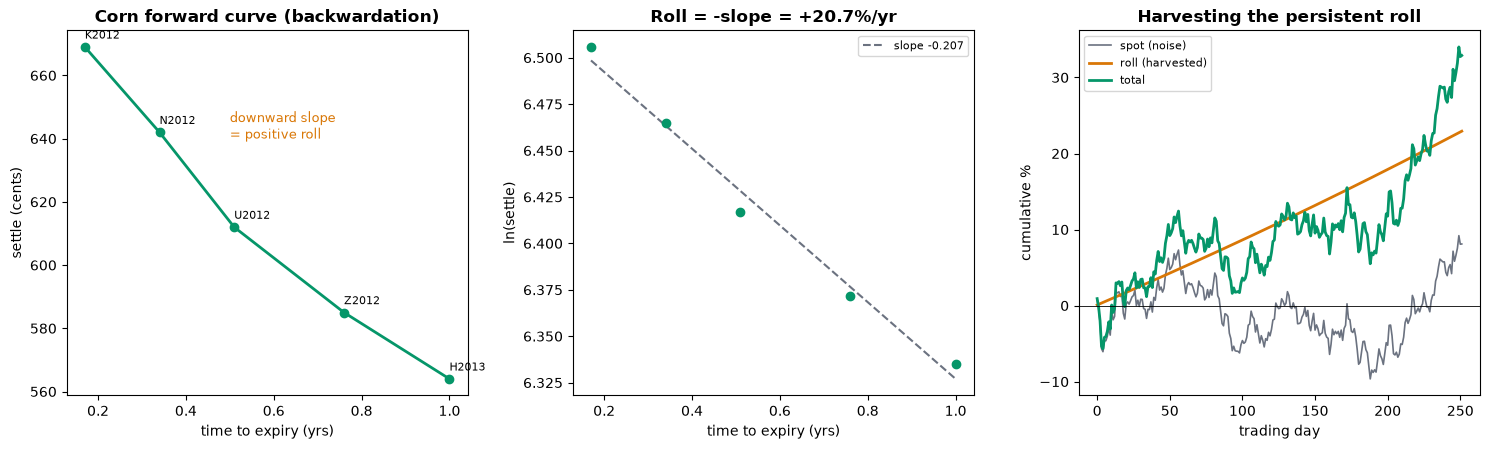

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
EM="#059669"; EM2="#34d399"; NEU="#6b7280"; AMB="#d97706"

# (1) Forward curve (price vs time-to-expiry) -> backwardation
ax[0].plot(corn.T_years, corn.settle, "o-", color=EM, lw=2)
ax[0].set_title("Corn forward curve (backwardation)", fontweight="bold")
ax[0].set_xlabel("time to expiry (yrs)"); ax[0].set_ylabel("settle (cents)")
for x,y,m in zip(corn.T_years, corn.settle, months):
    ax[0].annotate(m, (x,y), fontsize=8, xytext=(0,6), textcoords="offset points")
ax[0].text(0.5, 640, "downward slope\n= positive roll", color=AMB, fontsize=9)

# (2) log curve with the fitted slope -> roll = -slope
xx = np.linspace(corn.T_years.min(), corn.T_years.max(), 50)
ax[1].scatter(corn.T_years, corn.log_price, color=EM, zorder=5)
ax[1].plot(xx, intercept + slope*xx, "--", color=NEU, label=f"slope {slope:+.3f}")
ax[1].set_title(f"Roll = -slope = {roll_corn*100:+.1f}%/yr", fontweight="bold")
ax[1].set_xlabel("time to expiry (yrs)"); ax[1].set_ylabel("ln(settle)"); ax[1].legend(fontsize=8)

# (3) cumulative: spot is noise, roll is the harvested edge
ax[2].plot(cum_spot*100, color=NEU, lw=1.2, label="spot (noise)")
ax[2].plot(cum_roll*100, color=AMB, lw=2, label="roll (harvested)")
ax[2].plot(cum_total*100, color=EM, lw=2, label="total")
ax[2].axhline(0, color="black", lw=0.6)
ax[2].set_title("Harvesting the persistent roll", fontweight="bold")
ax[2].set_xlabel("trading day"); ax[2].set_ylabel("cumulative %"); ax[2].legend(fontsize=8)

plt.tight_layout(); plt.savefig("chart_1_roll.png", dpi=115, bbox_inches="tight")
print("saved chart_1_roll.png")

## 8. The one-paragraph version

Momentum is best understood in **futures**, and the engine is the **roll return** — the part of a
future's total return left after the **spot** move (*total = spot + roll*). For the **E-mini** you
can derive it *exactly* by arbitrage against SPY: **roll = dividend yield − interest rate** (and for
an FX future like the **peso**, roll = the **interest-rate differential** — pure carry). The sign has
names: **positive roll = normal backwardation** (downward forward curve), **negative roll =
contango** — Keynes explained backwardation as the premium paid to speculators for taking the long
side from hedging farmers. Model futures prices as **linear in log-time**, $\ln F = \alpha t -
\gamma T$, so the **roll return γ = −(slope of the log forward curve)**; on the corn snapshot that
slope gives a **positive, backwardated roll** of roughly **+21%/yr**. We use **log returns** because
they're **additive** and can be **normal** (net returns are floored at −1). The causal payoff: roll
returns **persist**, so you harvest a predictable edge **without** ever forecasting the noisy spot
price — which is exactly why CTAs trade momentum in futures.


---

# Additive source-backed continuation

The following cells are appended without changing the original notebook cells.


# EFS-03 resource addendum

This additive notebook preserves the original notebook and adds source-backed controls for futures roll strategies.

In [ ]:
import pandas as pd
from pathlib import Path
base = Path('.')
files = ['efs03_roll_formula_reference.csv','efs03_futures_data_hygiene.csv','efs03_gold_hedge_reference.csv','efs03_timestamp_alignment_demo.csv','efs03_sharpe_funding_cases.csv','efs03_back_adjustment_demo.csv']
data = {f: pd.read_csv(base / f) for f in files}
{k: v.shape for k, v in data.items()}

## 1. Roll formulas and causal framework

Exact arbitrage formulas apply to ES and FX futures; commodities usually require estimating roll from the forward curve.

In [ ]:
roll = data['efs03_roll_formula_reference.csv']
print(roll[['instrument','roll_formula','example_roll']].to_string(index=False))
assert roll['instrument'].str.contains('E-mini').any()
assert roll['roll_formula'].str.contains('slope of log futures').any()

## 2. Data hygiene controls

The transcript adds implementation details: continuous futures need back-adjustment, paired markets need matching timestamps, and spot hedges must not cancel the roll edge.

In [ ]:
hygiene = data['efs03_futures_data_hygiene.csv']
print(hygiene[['control','correct_action']].to_string(index=False))
assert hygiene['control'].str.contains('Timestamp').any()
assert hygiene['control'].str.contains('Back-adjusted').any()

## 3. Spot hedge selection

GLD is a direct enough gold spot proxy for the GC exercise. USO is not a good crude spot hedge for roll harvesting because it holds futures. XLE is only a partial proxy because it adds equity/company risks.

In [ ]:
hedges = data['efs03_gold_hedge_reference.csv']
print(hedges.to_string(index=False))
assert hedges.query("spot_proxy == 'USO'")['works'].iloc[0] == 'no'
assert hedges.query("spot_proxy == 'GLD'")['works'].iloc[0] == 'yes'

## 4. Timestamp mismatch and back-adjustment demos

These are small synthetic demonstrations of the two backtest bugs described in the transcript.

In [ ]:
ts = data['efs03_timestamp_alignment_demo.csv']
backadj = data['efs03_back_adjustment_demo.csv']
print(ts[['mismatched_spread','aligned_spread']].agg(['mean','std']).round(4))
print(backadj[['day','stitched_price','back_adjusted_price','return_label']].to_string(index=False))
assert abs(ts['mismatched_spread'].mean() - ts['aligned_spread'].mean()) > 0.01
assert 'not real P&L' in set(backadj['return_label'])

## 5. Sharpe funding treatment

The risk-free rate is not always subtracted. The funding treatment depends on whether cash remains available or is spent on the hedge.

In [ ]:
sharpe = data['efs03_sharpe_funding_cases.csv']
print(sharpe.to_string(index=False))
assert sharpe.query("strategy_case == 'Short GC future plus long GLD'")['subtract_risk_free'].iloc[0] == 'yes'